<a href="https://colab.research.google.com/github/manavsharma111/Machine-Learning/blob/main/Network_inrtution_detection_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [4]:
df = pd.read_csv("Train.csv")
df.head()

,0,tcp,ftp_data,SF,491,0.1,0.2,0.3,0.4,0.5,...,0.17,0.03,0.17.1,0.00.6,0.00.7,0.00.8,0.05,0.00.9,normal,20
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

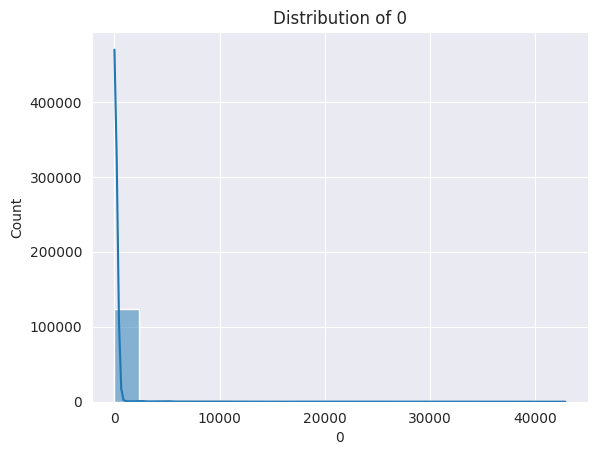

In [24]:
feature = numeric_features[0]

plt.figure()
sns.histplot(df[feature], kde=True)
plt.title(f"Distribution of {feature}")
plt.show()

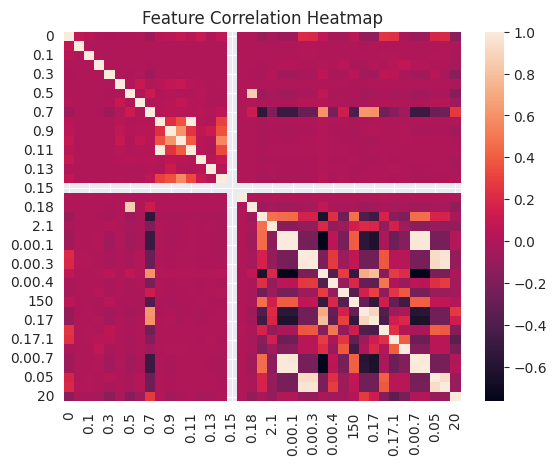

In [23]:
plt.figure()
corr = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(corr, annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

In [7]:
X = df.drop("normal", axis=1)
y = df["normal"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [12]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [13]:
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42
)

iso_forest.fit(X_train_processed)

IsolationForest(contamination=0.01, random_state=42)

In [14]:
iso_pred = iso_forest.predict(X_test_processed)

# Convert labels: -1 → anomaly (1), 1 → normal (0)
iso_pred = np.where(iso_pred == -1, 1, 0)

print("Isolation Forest Predictions:")
print(pd.Series(iso_pred).value_counts())

Isolation Forest Predictions:
0    24966
1      229
Name: count, dtype: int64


In [15]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_processed, y_train)

RandomForestClassifier(random_state=42)

In [17]:
rf_pred = rf_model.predict(X_test_processed)

print("Random Forest Predictions:")
print(pd.Series(rf_pred).value_counts())

Random Forest Predictions:
normal             13394
neptune             8239
satan                745
ipsweep              743
portsweep            583
smurf                551
nmap                 303
back                 201
teardrop             196
warezclient          176
pod                   36
guess_passwd          11
buffer_overflow        7
warezmaster            4
imap                   2
perl                   1
land                   1
multihop               1
phf                    1
Name: count, dtype: int64


In [18]:
results_df = pd.DataFrame({
    "IsolationForest_Anomaly": iso_pred,
    "RandomForest_Prediction": rf_pred
})

results_df.head()

,IsolationForest_Anomaly,RandomForest_Prediction
0,0,neptune
1,0,nmap
2,0,normal
3,0,neptune
4,0,nmap


In [19]:
anomaly_scores = iso_forest.decision_function(X_test_processed)

results_df["Anomaly_Score"] = anomaly_scores

results_df.head()

,IsolationForest_Anomaly,RandomForest_Prediction,Anomaly_Score
0,0,neptune,0.106671
1,0,nmap,0.033516
2,0,normal,0.125186
3,0,neptune,0.060703
4,0,nmap,0.033640


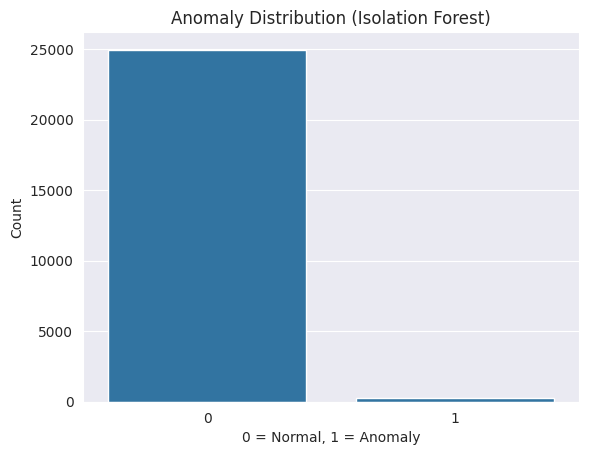

In [21]:
plt.figure()
sns.countplot(x=iso_pred)
plt.title("Anomaly Distribution (Isolation Forest)")
plt.xlabel("0 = Normal, 1 = Anomaly")
plt.ylabel("Count")
plt.show()

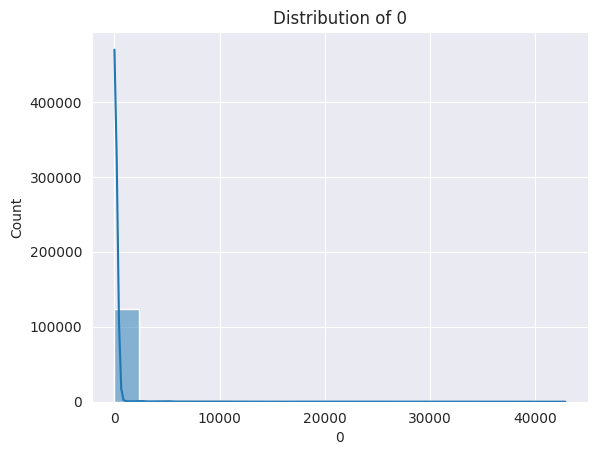

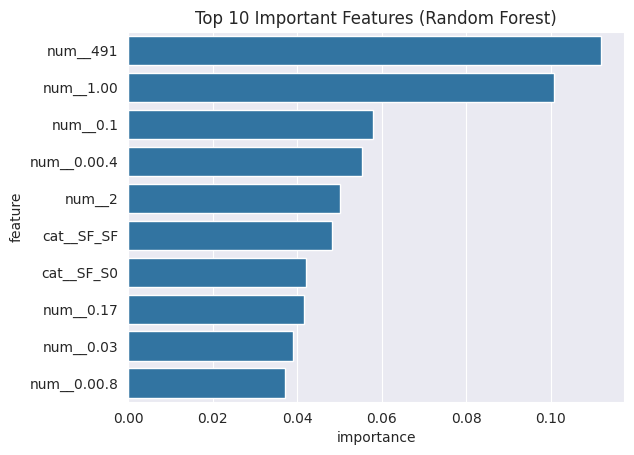

In [26]:
importances = rf_model.feature_importances_

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

plt.figure()
sns.barplot(x="importance", y="feature", data=importance_df.head(10))
plt.title("Top 10 Important Features (Random Forest)")
plt.show()

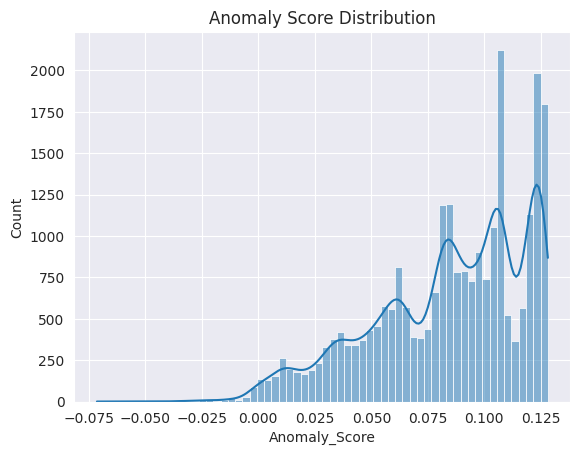

In [27]:
plt.figure()
sns.histplot(results_df["Anomaly_Score"], kde=True)
plt.title("Anomaly Score Distribution")
plt.show()

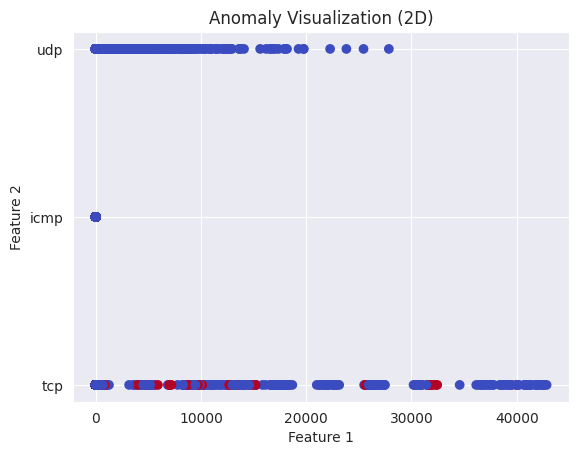

In [28]:
plt.figure()

plt.scatter(
    X_test.iloc[:, 0],
    X_test.iloc[:, 1],
    c=iso_pred,
    cmap='coolwarm'
)

plt.title("Anomaly Visualization (2D)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

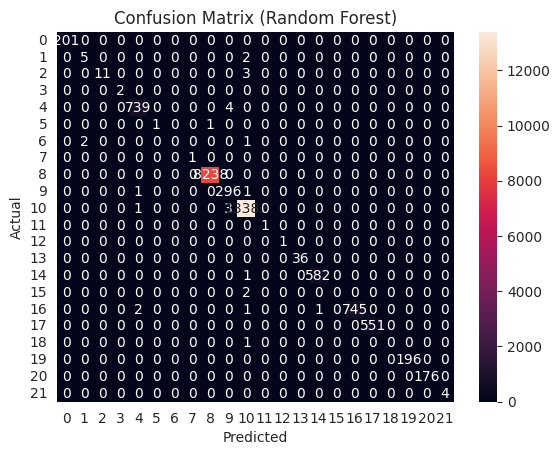

In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

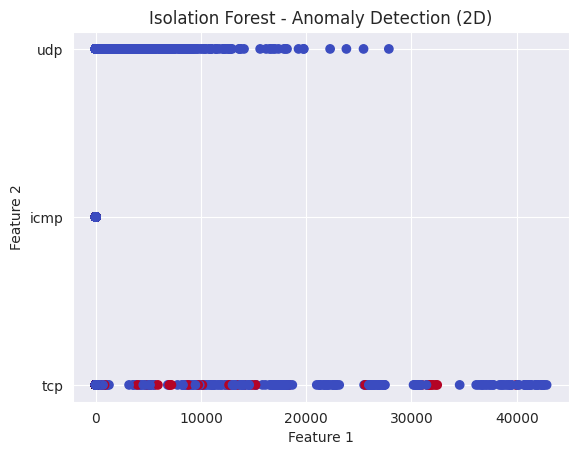

In [33]:
plt.figure()

plt.scatter(
    X_test.iloc[:, 0],
    X_test.iloc[:, 1],
    c=iso_pred,
    cmap='coolwarm'
)

plt.title("Isolation Forest - Anomaly Detection (2D)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

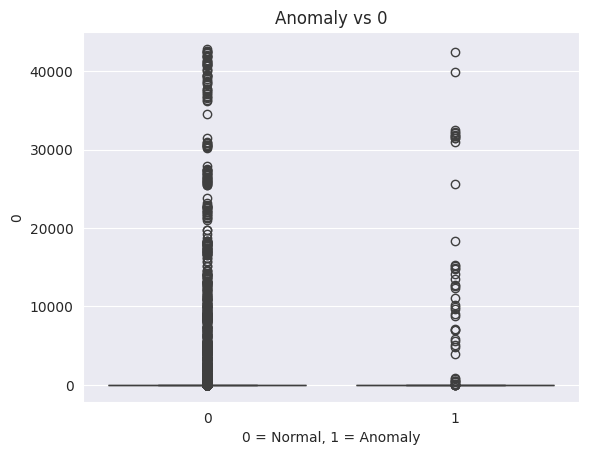

In [34]:
feature = numeric_features[0]

plt.figure()
sns.boxplot(x=iso_pred, y=X_test[feature])
plt.title(f"Anomaly vs {feature}")
plt.xlabel("0 = Normal, 1 = Anomaly")
plt.show()

In [ ]:
sample_df = X_test.copy()
sample_df['Anomaly'] = iso_pred

sns.pairplot(sample_df.sample(300), hue='Anomaly')
plt.show()

In [ ]:
plt.figure()

plt.plot(range(len(iso_pred)), iso_pred)
plt.title("Anomaly Timeline")
plt.xlabel("Time Index")
plt.ylabel("Anomaly (1) / Normal (0)")
plt.show()